In [1]:
from hossam import load_data
from pandas import DataFrame, get_dummies
from matplotlib import pyplot as plt
from matplotlib import font_manager as fm 
import seaborn as sb
import numpy as np
import statsmodels.api as sm
from sklearn.metrics import confusion_matrix, roc_curve, accuracy_score, recall_score,  precision_score, f1_score


In [2]:
my_dpi = 200
my_font_name = "./NotoSansKr-Regular.ttf"
fm.fontManager.addfont(fpath)
fprop = fm.FontProperties(fname=fpath)
fname = fprop.get_name()
plt.rcParams['font.family'] = fname
plt.rcParams['font.size'] = 6
plt.rcParams['axes.unicode_minus'] = False

In [3]:
origin = load_data('graduate')
print("\n===== 데이터 크기 확인 =====")
print(f"데이터셋 크기: {origin.shape}")
print(f"열 개수: {origin.shape[1]}")
print(f"행 개수: {origin.shape[0]}")
print("\n===== 타입확인 =====")
print(origin.info())
origin.head()

[data] https://data.hossam.kr/data/lab12_/graduate.xlsx
[desc] 방사선학 석사과정 대학원생 모집 현황을 조사한 가상의 데이터
[!] Cannot read metadata

===== 데이터 크기 확인 =====
데이터셋 크기: (400, 4)
열 개수: 4
행 개수: 400

===== 타입확인 =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   합격여부    400 non-null    int64  
 1   필기점수    400 non-null    int64  
 2   학부성적    400 non-null    float64
 3   병원경력    400 non-null    object 
dtypes: float64(1), int64(2), object(1)
memory usage: 12.6+ KB
None


,합격여부,필기점수,학부성적,병원경력
0,0,380,3.61,1~5년
1,1,660,3.67,1~5년
2,1,800,4.00,10년 이상
3,1,640,3.19,1년 미만
4,0,520,2.93,1년 미만


병원경력의 종류 확인

In [4]:
origin['병원경력'].unique()

array(['1~5년', '10년 이상', '1년 미만', '5~10년'], dtype=object)

명목형 변수의 전처리<br>
데이터 라벨링<br>
값의 종류별로 0,1,2.....등의 숫자 체계로 변환<br>
라벨링 후, 탐색적 데이터분석을 위해서는 category타입으로 변환하는 것이 유리

In [5]:
df = origin.copy()
df['병원경력'] = df['병원경력'].map({
    '1년 미만':0, '1~5년':1, '5~10년':2, '10년 이상':3
})
df['병원경력'].unique()

array([1, 3, 0, 2])

명목형 변수의 더미변수 처리

In [6]:
# drop_first = True --> 다중공산성 방지
df2 = get_dummies(df,columns=['병원경력'], dtype='int',drop_first=True)
df2.head()

,합격여부,필기점수,학부성적,병원경력_1,병원경력_2,병원경력_3
0,0,380,3.61,1,0,0
1,1,660,3.67,1,0,0
2,1,800,4.00,0,0,1
3,1,640,3.19,0,0,0
4,0,520,2.93,0,0,0


3.로지스틱 회귀분석

📝1.로지스틱 수행

In [7]:
yname = '합격여부'

x = df2.drop(yname, axis=1)
y=df[yname]

x_input = sm.add_constant(x)    # 독립변수에 상수항 추가
display(x_input)

fit = sm.Logit(y,x_input).fit()

tbl1 = fit.summary()

print(tbl1)


,const,필기점수,학부성적,병원경력_1,병원경력_2,병원경력_3
0,1.0,380,3.61,1,0,0
1,1.0,660,3.67,1,0,0
2,1.0,800,4.00,0,0,1
3,1.0,640,3.19,0,0,0
4,1.0,520,2.93,0,0,0
...,...,...,...,...,...,...
395,1.0,620,4.00,0,1,0
396,1.0,560,3.04,1,0,0
397,1.0,460,2.63,0,1,0
398,1.0,700,3.65,0,1,0


Optimization terminated successfully.
         Current function value: 0.573147
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                   합격여부   No. Observations:                  400
Model:                          Logit   Df Residuals:                      394
Method:                           MLE   Df Model:                            5
Date:                Mon, 15 Dec 2025   Pseudo R-squ.:                 0.08292
Time:                        15:41:24   Log-Likelihood:                -229.26
converged:                       True   LL-Null:                       -249.99
Covariance Type:            nonrobust   LLR p-value:                 7.578e-08
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -5.5414      1.138     -4.869      0.000      -7.772      -3.311
필기점수           0.0023      0.

3.이진분류의 평가

📝1.혼동행렬

📝2.혼동행렬

✏️실제 종속변수

In [8]:
y_true = df2['합격여부']
y_true

0      0
1      1
2      1
3      1
4      0
      ..
395    0
396    0
397    0
398    0
399    0
Name: 합격여부, Length: 400, dtype: int64

✏️로지스틱이 예측한 값

In [9]:
y_pred = fit.predict(x_input)
y_pred

0      0.172627
1      0.292175
2      0.738408
3      0.178385
4      0.118354
         ...   
395    0.488670
396    0.165504
397    0.181062
398    0.463667
399    0.300731
Length: 400, dtype: float64

✏️혼동행렬 구하기 위해 예측 결과를 이진값으로 변환<br>
50%초과인 경우 True, 그렇지 않을 경우 False로 변환

In [10]:
y_pred_fix = y_pred > 0.5
y_pred_fix

0      False
1      False
2       True
3      False
4      False
       ...  
395    False
396    False
397    False
398    False
399    False
Length: 400, dtype: bool

✏️혼동행렬

In [11]:
cm = confusion_matrix(y_true , y_pred_fix)
tn,fp,fn,tp = cm.ravel()
tn,fp,fn,tp

(np.int64(254), np.int64(19), np.int64(97), np.int64(30))

✏️혼동행렬을 DataFrame으로 변환

In [12]:
cmdf = DataFrame(cm, index=['Actual 0 (Tn/Fp)' , 'Actual 1 (Fn/Tp)'], columns=
                 ['Predicted(Negative)', 'Predicted(Positive)'])
cmdf

,Predicted(Negative),Predicted(Positive)
Actual 0 (Tn/Fp),254,19
Actual 1 (Fn/Tp),97,30


✏️혼동행렬 히트맵

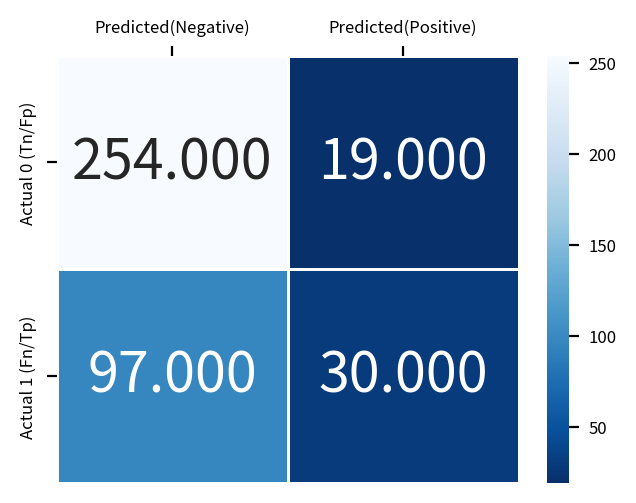

In [13]:
# 1) 그래프 초기화
width_px = 650 # 그래프 가로 크기
height_px = 500 # 그래프 세로 크기
rows = 1 # 그래프 행 수
cols = 1 # 그래프 열 수
figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)
# 2) heatmap 그리기
sb.heatmap(data=cmdf, annot=True, fmt="0.3f", linewidth=0.5,
cmap="Blues_r", annot_kws={"size": 20})
# 3) 그래프 꾸미기
ax.set_xlabel("")
ax.set_ylabel("")
ax.xaxis.tick_top() # x축의 변수 이름을 상단으로 이동
# 4) 출력
plt.tight_layout() # 여백 제거
plt.show() # 그래프 화면 출력
plt.close() # 그래프 작업 종료

✏️정확도(Accuaracy)

In [14]:
(tn+tp) / (tn +fp + fn + tp)

np.float64(0.71)

✏️쉽게 구하기

In [15]:
acc= accuracy_score(y_true, y_pred_fix)
acc

0.71

✏️4.정밀도(Precision)

In [16]:
# pre = tp /(fp + tp)
pre = precision_score(y_true, y_pred_fix)
pre

0.6122448979591837

✏️5.재현율(Recall, TPR)

In [17]:
recall = tp/(tp +fn)
recall = recall_score(y_true, y_pred_fix)
recall

0.23622047244094488

✏️위양성율, 거짓 양성 비율(Fallout, FPR)

In [18]:
# 함수가 지원되지 않는다,
fpr = fp/(fp +tn)
fpr

np.float64(0.0695970695970696)

✏️특이성(Specificity, TNR, True Negative Rate)

In [19]:
tnr = 1-fpr
tnr

np.float64(0.9304029304029304)

8.F1 Store

In [20]:
# f1 = 2 * ((pre*recall)/(pre + recall))
f1 = f1_score(y_true,y_pred_fix)
f1

0.3409090909090909

📝10.ROC Curve

In [21]:
from sklearn.metrics import roc_auc_score, roc_curve


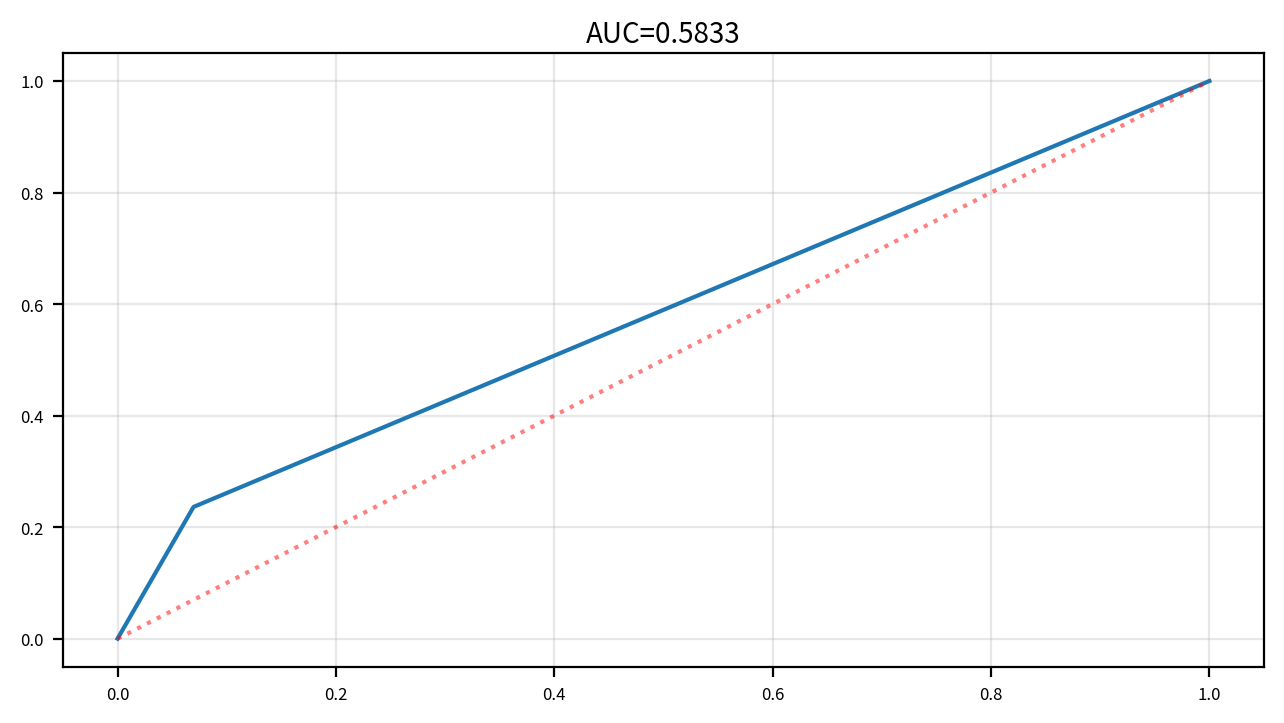

In [22]:

ras = roc_auc_score(y_true, y_pred_fix)

roc_fpr, roc_tpr, thresholds = roc_curve(y_true, y_pred_fix)

width_px = 1280
height_px = 720
rows = 1
cols=1
figsize = (width_px /my_dpi, height_px/my_dpi)
fig, ax = plt.subplots(rows,cols,figsize=figsize, dpi=my_dpi)

# 그래프 그리기->seaborn 사용
sb.lineplot(x=roc_fpr, y=roc_tpr)
sb.lineplot(x=[0,1],y=[0,1],color='red',linestyle=":", alpha=0.5)


        
ax.grid(True, alpha=0.3)
ax.set_title(f'AUC={ras:.4f}', fontsize=10, pad=4)

plt.tight_layout()
plt.show()
plt.close()

가운데 직선은ROC 곡선의 최저값으로, ROC Curve가 가운데 직선에 가까울수록 성능이 떨어지는 것이며,<br>
멀어질수록 성능이 뛰어난 것이다.<br>
ROC Curve는 FPR을 0부터 1까지 변화하면서 TPR의 변화 값을 구한다

📝AUC(Area Under Curve)

In [27]:
result_df = DataFrame({
    '설명력(Pseudo-Rsqe)':[fit.prsquared],
    '정확도(Accuracy)':[acc],
    '정밀도(Precision)':[pre],
    '재현율(Recall, TPR)':[recall],
    '위양성율(Fallout, FPR)':[fpr],
    '특이성(Specif city, TNR)':[tnr],
    'RAS':[ras],
    'f1_score':[f1]

})
result_df

,설명력(Pseudo-Rsqe),정확도(Accuracy),정밀도(Precision),"재현율(Recall, TPR)","위양성율(Fallout, FPR)","특이성(Specif city, TNR)",RAS,f1_score
0,0.082922,0.71,0.612245,0.23622,0.069597,0.930403,0.583312,0.340909


#04.Odds Ratio(오즈비 또는 승산비) <br>
Odds(오즈 또는 승산)<br>
$$Odds = \frac{이벤트~발생~확률}{이벤트~미발생~확률} = \frac{p}{1-p}$$
Odds Ratio(오즈비 또는 승산비)<br>

오즈비 계산
$$\text{Odds Ratio} = \frac{Tp/Fn}{FP/TN} = \frac{TP\times TN}{FP\times FN} $$

✏️계수 추출

In [29]:
coef = fit.params
coef

const    -5.541443
필기점수      0.002264
학부성적      0.804038
병원경력_1    0.211260
병원경력_2    0.876021
병원경력_3    1.551464
dtype: float64

✏️오즈 구하기

In [34]:
odds_rate= np.exp(coef)
odds_rate_df = DataFrame(odds_rate, columns=['odds_rate'])
print(f"10년 이상의 병원경력이 종속변수인 합격여부에 미치는 영향이 가장 크다고 볼 수 있다.")
odds_rate_df

10년 이상의 병원경력이 종속변수인 합격여부에 미치는 영향이 가장 크다고 볼 수 있다.


,odds_rate
const,0.003921
필기점수,1.002267
학부성적,2.234545
병원경력_1,1.235233
병원경력_2,2.401325
병원경력_3,4.718371


✏️오즈비

In [38]:
odds_ratio = (tp * tn) / (fp * fn)
odds_ratio

np.float64(4.134563212154097)

노출군의 사건 발생 오즈는 비노출군에 비해 약 4.13배 높은 것으로 나타났다. <br>
혹은 설명변수가 1단위 증가할 때 종속변수가 1이 될 오즈는 약 4.13배 증가한다

#05.가상의 데이터를 통한 예측

In [45]:
myinput = "480,4.3,0,0,1"
myinput = myinput.split(',')

x_new = DataFrame([{
    '필기점수':int(myinput[0].strip()),
    '학부성적':float(myinput[1].strip()),
    '병원경력_1':int(myinput[2].strip()),
    '병원경력_2':int(myinput[3].strip()),
    '병원경력_3':int(myinput[4].strip())
}])

x_new_input = sm.add_constant(x_new, has_constant = 'add')

myresult = fit.predict(x_new_input)
myresult

0    0.635134
dtype: float64

In [48]:
"당신의 합격 확룰은{0:0.2f}%입니다.".format(myresult[0]*100)

'당신의 합격 확룰은63.51%입니다.'

In [50]:
"합격" if myresult[0] > 0.5 else "불합격"

'합격'